# Evaluación 1 - Ciencia de Datos Espaciales

## Análisis espacial de usuarios de teléfonos móviles (MOBILES)

**Alumno:** Camila Salazar Cisneros
**Código:** 20190600



## 1. Importación de librerías

En esta sección se cargan las librerías necesarias para trabajar con datos espaciales, tablas de datos y generación de gráficos.

In [13]:
# Importamos GeoPandas para trabajar con información espacial
import geopandas as gpd

# Importamos Pandas para trabajar con tablas de datos
import pandas as pd

# Importamos Matplotlib para generar gráficos
import matplotlib.pyplot as plt

2. Carga de archivos

En esta sección se cargan los archivos entregados para el análisis: el GeoDataFrame con la información espacial de los países y el DataFrame con la variable MOBILES.

In [14]:
# Definimos la ruta del archivo espacial GeoPackage desde GitHub
linkWorldMaps = "https://raw.githubusercontent.com/CamilaSalazar73/Tarea1_CienciaDatosEspaciales/main/worldMaps.gpkg"

# Revisamos las capas disponibles dentro del GeoPackage
gpd.list_layers(linkWorldMaps)

,name,geometry_type
0,rivers,MultiLineString
1,cities,Point
2,countries,MultiPolygon


Cargamos la capa de países que contiene la información espacial para el análisis.

In [15]:
# Cargamos la capa de países del GeoPackage
countries = gpd.read_file(linkWorldMaps, layer="countries")

# Revisamos la información del GeoDataFrame
countries.head()

,COUNTRY,geometry
0,Aruba (Netherlands),"MULTIPOLYGON (((-69.88223 12.41111, -69.94695 ..."
1,Antigua and Barbuda,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
2,Afghanistan,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
3,Algeria,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
4,Azerbaijan,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."


Cargamos el DataFrame con la información de usuarios móviles.

In [16]:
# Definimos la ruta del archivo CSV
linkData = "https://raw.githubusercontent.com/CamilaSalazar73/Tarea1_CienciaDatosEspaciales/refs/heads/main/some_dataworld.csv"

# Cargamos los datos de usuarios móviles
mobiles = pd.read_csv(linkData)

# Revisamos los primeros registros
mobiles.head()

,Country,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,AFGHANISTAN,AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
1,ALBANIA,AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
2,ALGERIA,DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,ANGOLA,AO,AGO,AFRICA,87.8,19362000,1246700,107,37202061,25700000
4,ANTIGUA AND BARBUDA,AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000


Cargamos el DataFrame con la información de usuarios móviles.

In [26]:
import pandas as pd

someDataLink = "some_dataworld.csv"

someData = pd.read_csv("https://raw.githubusercontent.com/CamilaSalazar73/Tarea1_CienciaDatosEspaciales/main/" + someDataLink)

## data available
someData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       172 non-null    object 
 1   iso2          171 non-null    object 
 2   iso3          172 non-null    object 
 3   region        172 non-null    object 
 4   fragility     172 non-null    float64
 5   co2           172 non-null    int64  
 6   sq_km         172 non-null    int64  
 7   num_airports  172 non-null    int64  
 8   population    172 non-null    int64  
 9   mobiles       172 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 13.6+ KB


In [27]:
someData.head()

,Country,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,AFGHANISTAN,AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
1,ALBANIA,AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
2,ALGERIA,DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,ANGOLA,AO,AGO,AFRICA,87.8,19362000,1246700,107,37202061,25700000
4,ANTIGUA AND BARBUDA,AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000


Ver columnas del GeoDataFrame:

In [34]:
countries['Country'].head()

,Country
0,Aruba (Netherlands)
1,Antigua and Barbuda
2,Afghanistan
3,Algeria
4,Azerbaijan


In [35]:
mobiles['Country'].head()

,Country
0,AFGHANISTAN
1,ALBANIA
2,ALGERIA
3,ANGOLA
4,ANTIGUA AND BARBUDA


In [36]:
countries.Country.str.upper().head()

,Country
0,ARUBA (NETHERLANDS)
1,ANTIGUA AND BARBUDA
2,AFGHANISTAN
3,ALGERIA
4,AZERBAIJAN


Se observa que existen diferencias de mayúsculas en las claves. Trabajamos con letras mayúsculas para facilitar la unión.

In [37]:
countries['Country'] = countries.Country.str.upper()

Se identifican los países que no tienen coincidencia entre el GeoDataFrame y el DataFrame.

In [38]:
onlyDF = set(mobiles.Country) - set(countries.Country)
onlyGDF = set(countries.Country) - set(mobiles.Country)

Luego revisamos

In [39]:
onlyDF

{'BAHAMAS (THE)',
 'BOLIVIA (PLURINATIONAL STATE OF)',
 'BRUNEI DARUSSALAM',
 'CABO VERDE',
 'CENTRAL AFRICAN REPUBLIC (THE)',
 'COMOROS (THE)',
 'CONGO (THE DEMOCRATIC REPUBLIC OF THE)',
 'CONGO (THE)',
 "CÔTE D'IVOIRE",
 'DOMINICAN REPUBLIC (THE)',
 'ESWATINI',
 'GAMBIA (THE)',
 'IRAN (ISLAMIC REPUBLIC OF)',
 'KOREA (THE REPUBLIC OF)',
 "LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)",
 'MICRONESIA (FEDERATED STATES OF)',
 'MOLDOVA (THE REPUBLIC OF)',
 'NETHERLANDS (THE)',
 'NIGER (THE)',
 'NORTH MACEDONIA',
 'NORTHERN MARIANA ISLANDS (THE)',
 'PHILIPPINES (THE)',
 'RUSSIAN FEDERATION (THE)',
 'SAMOA',
 'SUDAN (THE)',
 'TANZANIA, THE UNITED REPUBLIC OF',
 'TIMOR-LESTE',
 'UNITED ARAB EMIRATES (THE)',
 'UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)',
 'UNITED STATES OF AMERICA (THE)'}

In [40]:
onlyGDF

{'AMERICAN SAMOA (US)',
 'AMERICAN VIRGIN ISLANDS (US)',
 'ANDORRA',
 'ANGUILLA (UK)',
 'ANTARCTICA',
 'ARUBA (NETHERLANDS)',
 'BAHAMAS',
 'BAKER ISLAND (US)',
 'BERMUDA (UK)',
 'BOLIVIA',
 'BONAIRE (NETHERLANDS)',
 'BOUVET ISLAND (NORWAY)',
 'BRITISH INDIAN OCEAN TERRITORY (UK)',
 'BRITISH VIRGIN ISLANDS(UK)',
 'BRUNEI',
 'CAPE VERDE',
 'CAYMAN ISLANDS (UK)',
 'CENTRAL AFRICAN REPUBLIC',
 'CHRISTMAS ISLAND (AUSTRALIA)',
 'COCOS (KEELING) ISLANDS (AUSTRALIA)',
 'COMOROS',
 'CONGO',
 'COOK ISLANDS (NEW ZEALAND)',
 'CURACAO (NETHERLANDS)',
 'CZECH REPUBLIC',
 'DEMOCRATIC REPUBLIC OF THE CONGO',
 'DOMINICA',
 'DOMINICAN REPUBLIC',
 'EAST TIMOR',
 'ERITREA',
 'FALKLAND ISLANDS (UK)',
 'FAROE ISLANDS (DENMARK)',
 'FEDERATED STATES OF MICRONESIA',
 'FRENCH GUIANA (FRANCE)',
 'FRENCH POLYNESIA (FRANCE)',
 'FRENCH SOUTHERN & ANTARCTIC LANDS (FRANCE)',
 'GAMBIA',
 'GIBRALTAR (UK)',
 'GLORIOSO ISLANDS (FRANCE)',
 'GREENLAND (DENMARK)',
 'GUADELOUPE (FRANCE)',
 'GUAM (US)',
 'GUERNSEY (UK)',
 'HE

Instalacion

In [41]:
!pip install thefuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.5 MB/s eta 0:00:00


Importacion

In [43]:
from thefuzz.process import extractOne as best

In [44]:
best('BAHAMAS (THE)', onlyGDF)

('BAHAMAS', 90)

Se realiza la comparación para todos los países sin coincidencia exacta.

In [49]:
[(country, best(country,onlyGDF)) for country in onlyDF]

[('IRAN (ISLAMIC REPUBLIC OF)', ('IRAN', 90)),
 ('UNITED ARAB EMIRATES (THE)', ('UNITED ARAB EMIRATES', 95)),
 ('COMOROS (THE)', ('COMOROS', 90)),
 ('DOMINICAN REPUBLIC (THE)', ('DOMINICAN REPUBLIC', 95)),
 ('NIGER (THE)', ('NIGER', 90)),
 ('BRUNEI DARUSSALAM', ('BRUNEI', 90)),
 ("LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)", ('DOMINICAN REPUBLIC', 86)),
 ('TANZANIA, THE UNITED REPUBLIC OF', ('TANZANIA', 90)),
 ('NORTHERN MARIANA ISLANDS (THE)', ('NORTHERN MARIANA ISLANDS (US)', 91)),
 ('ESWATINI', ('MARTINIQUE (FRANCE)', 60)),
 ('MICRONESIA (FEDERATED STATES OF)', ('FEDERATED STATES OF MICRONESIA', 95)),
 ('CONGO (THE DEMOCRATIC REPUBLIC OF THE)',
  ('DEMOCRATIC REPUBLIC OF THE CONGO', 95)),
 ('TIMOR-LESTE', ('EAST TIMOR', 81)),
 ('BOLIVIA (PLURINATIONAL STATE OF)', ('BOLIVIA', 90)),
 ('SAMOA', ('AMERICAN SAMOA (US)', 90)),
 ('GAMBIA (THE)', ('GAMBIA', 90)),
 ('UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)',
  ('UNITED KINGDOM', 90)),
 ('NETHERLANDS (THE)', ('NETHERLANDS', 95)

Se genera una lista con tres elementos: país original, mejor coincidencia y nivel de similitud.

In [50]:
[(country, best(country,onlyGDF)[0], best(country,onlyGDF)[1]) for country in onlyDF]

[('IRAN (ISLAMIC REPUBLIC OF)', 'IRAN', 90),
 ('UNITED ARAB EMIRATES (THE)', 'UNITED ARAB EMIRATES', 95),
 ('COMOROS (THE)', 'COMOROS', 90),
 ('DOMINICAN REPUBLIC (THE)', 'DOMINICAN REPUBLIC', 95),
 ('NIGER (THE)', 'NIGER', 90),
 ('BRUNEI DARUSSALAM', 'BRUNEI', 90),
 ("LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)", 'DOMINICAN REPUBLIC', 86),
 ('TANZANIA, THE UNITED REPUBLIC OF', 'TANZANIA', 90),
 ('NORTHERN MARIANA ISLANDS (THE)', 'NORTHERN MARIANA ISLANDS (US)', 91),
 ('ESWATINI', 'MARTINIQUE (FRANCE)', 60),
 ('MICRONESIA (FEDERATED STATES OF)', 'FEDERATED STATES OF MICRONESIA', 95),
 ('CONGO (THE DEMOCRATIC REPUBLIC OF THE)',
  'DEMOCRATIC REPUBLIC OF THE CONGO',
  95),
 ('TIMOR-LESTE', 'EAST TIMOR', 81),
 ('BOLIVIA (PLURINATIONAL STATE OF)', 'BOLIVIA', 90),
 ('SAMOA', 'AMERICAN SAMOA (US)', 90),
 ('GAMBIA (THE)', 'GAMBIA', 90),
 ('UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)',
  'UNITED KINGDOM',
  90),
 ('NETHERLANDS (THE)', 'NETHERLANDS', 95),
 ('RUSSIAN FEDERATION (THE)',

Convertimos la lista de coincidencias en un DataFrame para poder trabajar con ella.

In [51]:
pd.DataFrame([(country, best(country,onlyGDF)[0], best(country,onlyGDF)[1]) for country in onlyDF])

,0,1,2
0,IRAN (ISLAMIC REPUBLIC OF),IRAN,90
1,UNITED ARAB EMIRATES (THE),UNITED ARAB EMIRATES,95
2,COMOROS (THE),COMOROS,90
3,DOMINICAN REPUBLIC (THE),DOMINICAN REPUBLIC,95
4,NIGER (THE),NIGER,90
5,BRUNEI DARUSSALAM,BRUNEI,90
6,LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE),DOMINICAN REPUBLIC,86
7,"TANZANIA, THE UNITED REPUBLIC OF",TANZANIA,90
8,NORTHERN MARIANA ISLANDS (THE),NORTHERN MARIANA ISLANDS (US),91
9,ESWATINI,MARTINIQUE (FRANCE),60


Se ordenan los resultados según la columna 2, que corresponde al nivel de similitud.

In [52]:
pd.DataFrame([(country, best(country,onlyGDF)[0],best(country,onlyGDF)[1]) for country in onlyDF]).sort_values(by=2)

,0,1,2
26,CÔTE D'IVOIRE,IVORY COAST,58
9,ESWATINI,MARTINIQUE (FRANCE),60
28,CABO VERDE,CAPE VERDE,80
12,TIMOR-LESTE,EAST TIMOR,81
6,LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE),DOMINICAN REPUBLIC,86
24,KOREA (THE REPUBLIC OF),NORTH KOREA,86
5,BRUNEI DARUSSALAM,BRUNEI,90
0,IRAN (ISLAMIC REPUBLIC OF),IRAN,90
15,GAMBIA (THE),GAMBIA,90
14,SAMOA,AMERICAN SAMOA (US),90


Se revisan los países del GeoDataFrame que pueden generar conflictos durante la unión debido a diferencias de nombres o nombres similares.

In [53]:
countries.Country[countries.Country.str.contains('SWAZ|LAO|SAMOA|KORE')]

,Country
9,AMERICAN SAMOA (US)
120,NORTH KOREA
122,SOUTH KOREA
126,LAOS
242,WESTERN SAMOA
243,SWAZILAND


Se realizan correcciones manuales de los nombres de países que presentan diferencias entre ambas bases de datos para permitir una correcta unión (merge).

In [55]:
manualChanges={
    'SWAZILAND':'ESWATINI',
    'LAOS':"LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)",
    'SOUTH KOREA':'KOREA (THE REPUBLIC OF)',
    'WESTERN SAMOA':'SAMOA'
}

countries.replace(to_replace={'Country':manualChanges}, inplace=True)

Después de aplicar las correcciones, se vuelven a calcular las diferencias entre las bases de datos para verificar que los nombres coincidan.

In [56]:
onlyDF=set(someData.Country)-set(countries.Country)
onlyGDF=set(countries.Country)-set(someData.Country)

Se revisan nuevamente las coincidencias restantes utilizando similitud de nombres y considerando únicamente valores con alta coincidencia.

In [57]:
pd.DataFrame([(country, best(country,onlyGDF)[0],best(country,onlyGDF)[1]) for country in onlyDF]).sort_values(2)

,0,1,2
22,CÔTE D'IVOIRE,IVORY COAST,58
24,CABO VERDE,CAPE VERDE,80
10,TIMOR-LESTE,EAST TIMOR,81
0,IRAN (ISLAMIC REPUBLIC OF),IRAN,90
6,"TANZANIA, THE UNITED REPUBLIC OF",TANZANIA,90
13,UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN I...,UNITED KINGDOM,90
5,BRUNEI DARUSSALAM,BRUNEI,90
2,COMOROS (THE),COMOROS,90
15,RUSSIAN FEDERATION (THE),RUSSIA,90
12,GAMBIA (THE),GAMBIA,90


Luego de identificar las coincidencias con alta similitud, se generan las equivalencias entre los nombres de países para actualizar la base de datos y permitir la unión correcta con el GeoDataFrame.

In [58]:
changesToDF={country: best(country,onlyGDF)[0] for country in onlyDF}
changesToDF

{'IRAN (ISLAMIC REPUBLIC OF)': 'IRAN',
 'UNITED ARAB EMIRATES (THE)': 'UNITED ARAB EMIRATES',
 'COMOROS (THE)': 'COMOROS',
 'DOMINICAN REPUBLIC (THE)': 'DOMINICAN REPUBLIC',
 'NIGER (THE)': 'NIGER',
 'BRUNEI DARUSSALAM': 'BRUNEI',
 'TANZANIA, THE UNITED REPUBLIC OF': 'TANZANIA',
 'NORTHERN MARIANA ISLANDS (THE)': 'NORTHERN MARIANA ISLANDS (US)',
 'MICRONESIA (FEDERATED STATES OF)': 'FEDERATED STATES OF MICRONESIA',
 'CONGO (THE DEMOCRATIC REPUBLIC OF THE)': 'DEMOCRATIC REPUBLIC OF THE CONGO',
 'TIMOR-LESTE': 'EAST TIMOR',
 'BOLIVIA (PLURINATIONAL STATE OF)': 'BOLIVIA',
 'GAMBIA (THE)': 'GAMBIA',
 'UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)': 'UNITED KINGDOM',
 'NETHERLANDS (THE)': 'NETHERLANDS',
 'RUSSIAN FEDERATION (THE)': 'RUSSIA',
 'NORTH MACEDONIA': 'MACEDONIA',
 'CENTRAL AFRICAN REPUBLIC (THE)': 'CENTRAL AFRICAN REPUBLIC',
 'PHILIPPINES (THE)': 'PHILIPPINES',
 'UNITED STATES OF AMERICA (THE)': 'UNITED STATES',
 'BAHAMAS (THE)': 'BAHAMAS',
 'SUDAN (THE)': 'SUDAN',
 

In [59]:
someData.replace(to_replace={'Country':changesToDF}, inplace=True)

Se actualizan nuevamente las diferencias entre ambas bases para verificar qué países aún no coinciden.

In [60]:
onlyDF=set(someData.Country)-set(countries.Country)
onlyGDF=set(countries.Country)-set(someData.Country)

[(country, best(country,onlyGDF)) for country in onlyDF]

[]

In [61]:
theMapAndData=countries.merge(someData, on='Country')

Se analiza la distribución espacial de una variable mediante un mapa de densidad de puntos (Dot Density Map), donde cada punto representa una cantidad determinada del fenómeno estudiado.

In [62]:
theMapAndData.region.value_counts()

,count
region,
AFRICA,52
EUROPE,37
MIDDLE EAST,16
CENTRAL AMERICA AND THE CARIBBEAN,16
EAST AND SOUTHEAST ASIA,15
SOUTH AMERICA,12
SOUTH ASIA,8
AUSTRALIA AND OCEANIA,7
CENTRAL ASIA,6


Se selecciona las regiones Norte, Sur, Centro America y Caribe.



<Axes: >

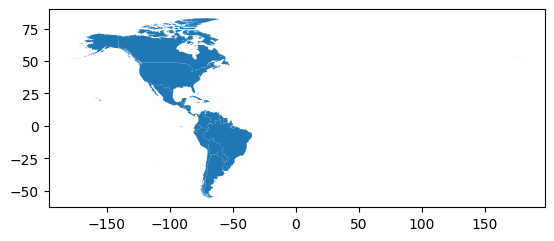

In [69]:
America=theMapAndData[
    theMapAndData.region.isin([
        'CENTRAL AMERICA AND THE CARIBBEAN',
        'SOUTH AMERICA',
        'NORTH AMERICA'
    ])
]

America.plot()

DDM (Dot Density Map)

Se define la cantidad representada por cada punto del mapa. Para ello se crea una nueva variable que indica el número de puntos según la población de cada país.

In [70]:
justDots=America.copy()

dot_value = 100000

justDots['num_dots'] = (justDots['population'] / dot_value).astype(int)

Se generan ubicaciones aleatorias de los puntos dentro de cada polígono para representar la distribución espacial.

In [71]:
justDots = justDots.sample_points(size=justDots['num_dots']).explode(index_parts=True)

In [72]:
justDots

0    0        POINT (-61.80569 17.1536)
7    0      POINT (-68.46559 -49.56804)
     1      POINT (-68.51506 -53.60331)
     2         POINT (-69.55 -51.50017)
     3      POINT (-60.15013 -36.37598)
                       ...             
161  307       POINT (-70.1005 8.89608)
     308       POINT (-62.59868 8.9951)
     309      POINT (-70.07808 10.3302)
     310      POINT (-60.19346 8.06728)
     311      POINT (-66.17528 5.29008)
Name: sampled_points, Length: 10423, dtype: geometry

In [73]:
type(justDots)

geopandas.geoseries.GeoSeries

Quitar el multiíndice y crear GeoDataFrame de puntos

Se elimina el índice múltiple generado durante la distribución de puntos para obtener un GeoDataFrame con una estructura más simple.

In [76]:
justDots.reset_index(drop=True, inplace=True)

America_dots=gpd.GeoDataFrame(geometry=justDots)

America_dots

,geometry
0,POINT (-61.80569 17.1536)
1,POINT (-68.46559 -49.56804)
2,POINT (-68.51506 -53.60331)
3,POINT (-69.55 -51.50017)
4,POINT (-60.15013 -36.37598)
...,...
10418,POINT (-70.1005 8.89608)
10419,POINT (-62.59868 8.9951)
10420,POINT (-70.07808 10.3302)
10421,POINT (-60.19346 8.06728)


Se verifica la estructura del GeoDataFrame generado con los puntos distribuidos.

In [77]:
America_dots.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 10423 entries, 0 to 10422
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  10423 non-null  geometry
dtypes: geometry(1)
memory usage: 81.6 KB


Se grafican los polígonos de los países como base y los puntos generados como una capa superior para representar la distribución espacial.

<Axes: >

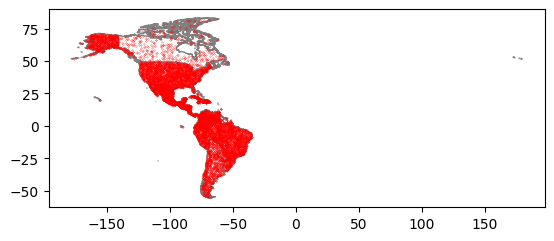

In [78]:
base=America.plot(facecolor="white",
                  edgecolor='grey')

America_dots.plot(markersize=0.05, color='red', ax=base)

Se utiliza una proyección de igual área para mejorar la representación de densidad y reducir distorsiones en la superficie del mapa.

<Axes: >

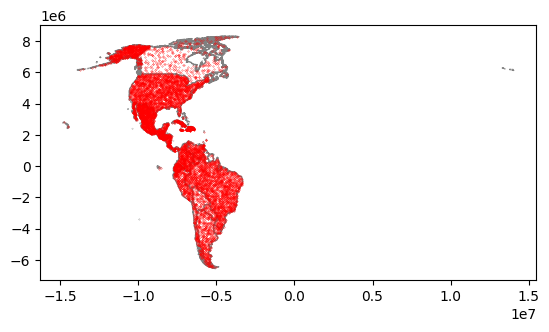

In [79]:
base=America.to_crs(8857).plot(facecolor="white",
                               edgecolor='grey')

America_dots.to_crs(8857).plot(markersize=0.05,
                               color='red',
                               ax=base)

Se mantienen las capas con la proyección seleccionada para continuar con el análisis espacial.

In [80]:
America_8857=America.to_crs(8857)

America_dots_8857=America_dots.to_crs(8857)

Proportional Symbol Map

Se generan puntos representativos para ubicar los símbolos proporcionales según la cantidad de usuarios de teléfonos móviles de cada país.

In [85]:
America_8857_centroids = America_8857.copy()

America_8857_centroids['geometry'] = America_8857_centroids['geometry'].centroid

Definir tamaño del símbolo usando MOBILES

In [87]:
America_8857_centroids.columns

Index(['Country', 'geometry', 'iso2', 'iso3', 'region', 'fragility', 'co2',
       'sq_km', 'num_airports', 'population', 'mobiles'],
      dtype='object')

In [88]:
America_8857_centroids['size'] = America_8857_centroids['mobiles'].apply(lambda x: x**0.5/100)

Se genera el mapa de símbolos proporcionales, donde el tamaño de cada círculo representa la cantidad de usuarios de teléfonos móviles (mobiles) por país.

<Axes: >

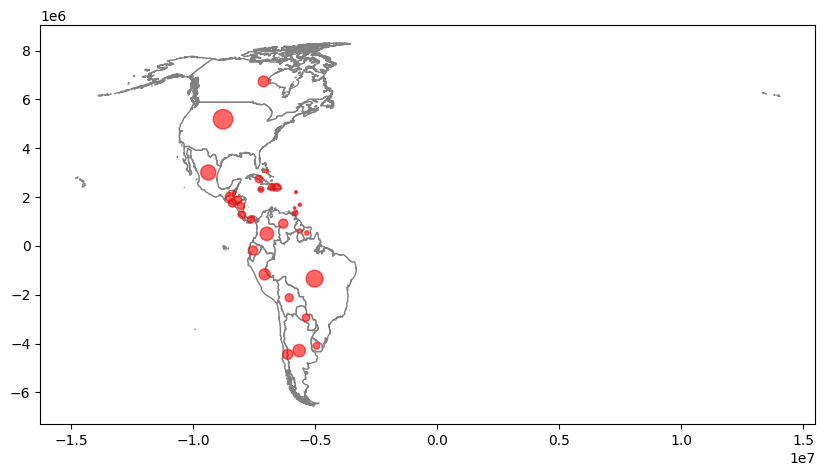

In [89]:
base = America_8857.plot(
    facecolor="white",
    edgecolor="grey",
    figsize=(10,10)
)

America_8857_centroids.plot(
    ax=base,
    markersize=America_8857_centroids['size'],
    color="red",
    alpha=0.6
)

# Thematics: Choropleths

Se observa la variable mobiles sin normalizar. Este mapa no representa correctamente un choropleth porque depende del tamaño de cada país.

<Axes: >

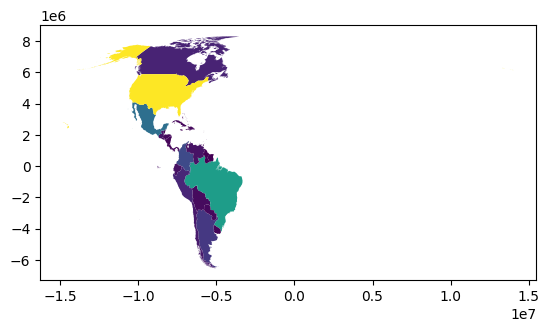

In [92]:
America_8857.plot(
    America_8857.mobiles
)

Se normaliza la variable para comparar la proporción de usuarios móviles respecto a la población.

<Axes: >

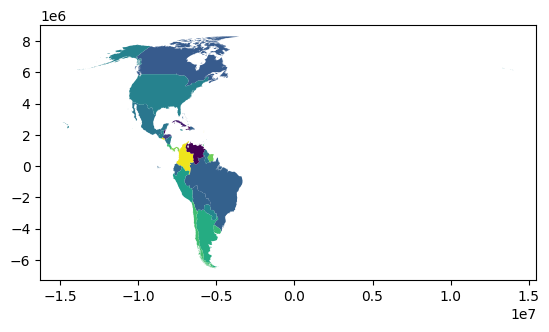

In [96]:
America_8857.plot(America_8857.mobiles/America_8857.population)